# Notebook 03 . Statistiques exploratoires et visualisations

Avant de plonger dans les analyses de NLP, on a besoin d'une **vue d'ensemble** du corpus.
Ce notebook produit les statistiques descriptives et les graphiques qui permettent
de comprendre la structure des données : quels partis parlent le plus de VSS,
comment ça évolue dans le temps, quels mots-clés dominent chez qui.

On termine par des synthèses produites par un LLM (Mistral, hébergé sur les serveurs de l'ENSAE)
qui résument la position de chaque bloc idéologique sur les VSS.

## Ce qu'on utilise
- `df_vss_propre.pkl` (les 10 377 prises de parole VSS nettoyées, notebook 02)
- `df_global.pkl` (toutes les prises de parole, pour calculer des proportions)

## Ce qu'on produit
- Les graphiques clés du projet (barplots, evolution temporelle, heatmaps)
- Des fichiers texte par parti (pour les synthèses LLM)
- Un fichier de synthèses par bloc idéologique

## 1. Imports et chargement

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import re, os
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE_PASTEL = ["#A8D8EA", "#AA96DA", "#FCBAD3", "#FFFFD2", "#B5EAD7",
                  "#C7CEEA", "#FFB7B2", "#E2F0CB", "#FFDAC1", "#B5B8FF"]

from config import COULEURS_BLOCS, ORDRE_BLOCS

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11, 'font.weight': 'light',
    'axes.titlesize': 13, 'axes.titleweight': 'normal',
    'axes.labelsize': 11, 'axes.labelweight': 'light',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.color': '#DDDDDD',
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.color': '#333333', 'ytick.color': '#333333', 'text.color': '#222222',
})


# Chargement
chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
if not os.path.exists(chemin_propre):
    chemin_propre = "/home/onyxia/work/projet_eco_socio/dataframes/df_vss_propre.pkl"

df_vss = pd.read_pickle(chemin_propre)
print(f"{len(df_vss)} prises de parole VSS chargees.")
print(f"Blocs : {df_vss['bloc'].value_counts().to_dict()}")

chemin_global = "/home/onyxia/work/projet_eco_socio/df_global.pkl"
if os.path.exists(chemin_global):
    df_global = pd.read_pickle(chemin_global)
    print(f"{len(df_global)} prises de parole globales (pour normalisation).")
    HAS_GLOBAL = True
else:
    print("df_global.pkl introuvable. Les stats normalisées ne seront pas disponibles.")
    HAS_GLOBAL = False

DOSSIER_ANALYSES = "/home/onyxia/work/projet_eco_socio/analyses"
os.makedirs(DOSSIER_ANALYSES, exist_ok=True)

4052 prises de parole VSS chargees.
Blocs : {'Centre': 1316, 'Gauche Radicale': 986, 'Gauche Modérée': 646, 'Droite Traditionnelle': 580, 'Extrême Droite': 524}


309123 prises de parole globales (pour normalisation).


## 2. Quels partis parlent le plus de VSS ?

Ce premier graphique montre le **volume brut** de prises de parole contenant
des mots-clés VSS, par parti. Attention a l'interprétation : un parti avec un gros
groupe parlementaire aura mécaniquement plus de prises de parole, même s'il ne
consacre pas une proportion élevée de ses interventions aux VSS.
C'est pour ça qu'on fait aussi la normalisation juste après.

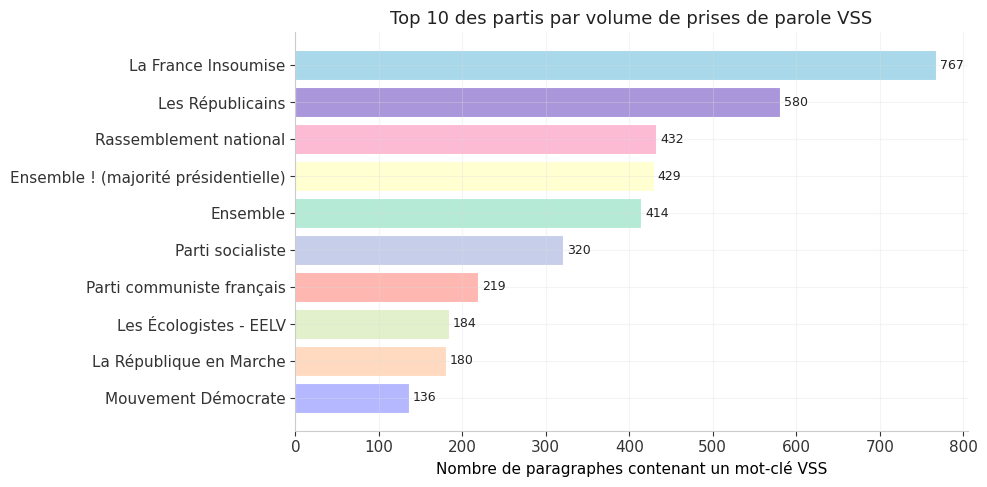

In [3]:
vss_counts = df_vss['nom_parti'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE_PASTEL[i % len(PALETTE_PASTEL)] for i in range(len(vss_counts))]
ax.barh(vss_counts.index, vss_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(vss_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
ax.set_xlabel("Nombre de paragraphes contenant un mot-clé VSS")
ax.set_title("Top 10 des partis par volume de prises de parole VSS")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Statistiques normalisées

Pour comparer équitablement, on calcule la **proportion** de prises de parole
consacrées aux VSS : combien de % de ses interventions un parti consacre-t-il aux VSS ?
Cela neutralise l'effet de taille des groupes parlementaires.

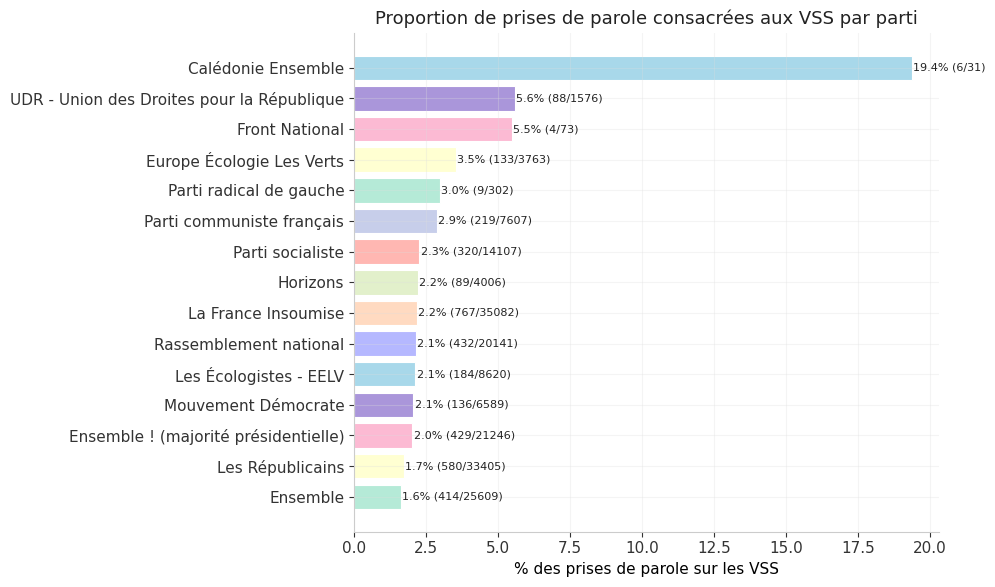

In [4]:
if HAS_GLOBAL:
    total_par_parti = df_global.groupby('nom_parti').size().reset_index(name='total')
    vss_par_parti = df_vss.groupby('nom_parti').size().reset_index(name='vss')
    stats = total_par_parti.merge(vss_par_parti, on='nom_parti', how='left')
    stats['vss'] = stats['vss'].fillna(0)
    stats['proportion_vss'] = stats['vss'] / stats['total'] * 100
    stats = stats.sort_values('proportion_vss', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETTE_PASTEL[i % len(PALETTE_PASTEL)] for i in range(len(stats))]
    ax.barh(stats['nom_parti'], stats['proportion_vss'], color=colors, edgecolor='white', linewidth=0.8)
    for i, row in enumerate(stats.itertuples()):
        ax.text(row.proportion_vss + 0.05, i,
                f"{row.proportion_vss:.1f}% ({int(row.vss)}/{int(row.total)})",
                va='center', fontsize=8)
    ax.set_xlabel("% des prises de parole sur les VSS")
    ax.set_title("Proportion de prises de parole consacrées aux VSS par parti")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Stats normalisées non disponibles (df_global manquant).")

## 4. Evolution temporelle

Comment le nombre de prises de parole sur les VSS évolue-t-il mois par mois ?
Les pics correspondent souvent a des événements médiatiques (affaires, lois débattues)
ou a des périodes législatives intenses.

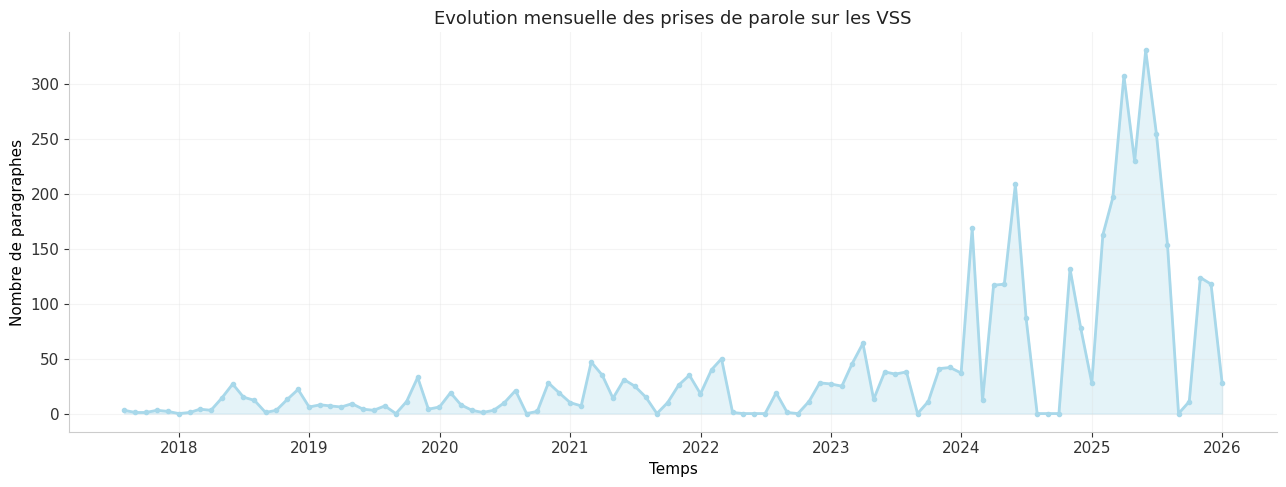

In [5]:
df_vss['date'] = pd.to_datetime(df_vss['date'])
evolution = df_vss.resample('ME', on='date').size()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(evolution.index, evolution.values, alpha=0.3, color=PALETTE_PASTEL[0])
ax.plot(evolution.index, evolution.values, color=PALETTE_PASTEL[0], lw=2, marker='o', markersize=3)
ax.set_xlabel("Temps")
ax.set_ylabel("Nombre de paragraphes")
ax.set_title("Evolution mensuelle des prises de parole sur les VSS")
plt.tight_layout()
plt.show()

## 5. Evolution par bloc idéologique

Est-ce que tous les blocs parlent de plus en plus de VSS, ou est-ce que
certains ont augmenté leur prise de parole plus que d'autres ?

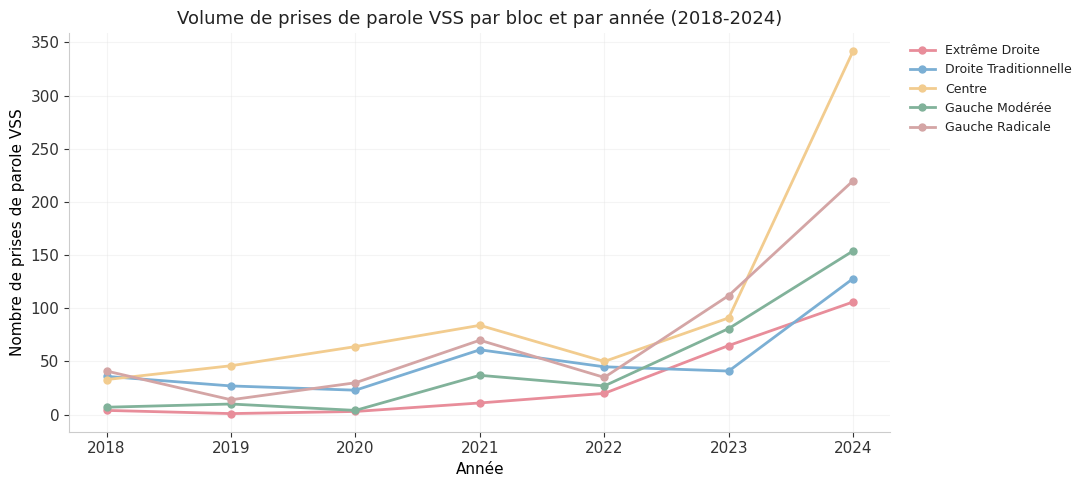

In [6]:
df_vss['annee_int'] = df_vss['date'].dt.year

df_vss_filtre = df_vss[(df_vss['annee_int'] >= 2018) & (df_vss['annee_int'] < 2025)]

evol_bloc = df_vss_filtre.groupby(['annee_int', 'bloc']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(11, 5))
for bloc in ORDRE_BLOCS:
    sub = evol_bloc[evol_bloc['bloc'] == bloc].sort_values('annee_int')
    if sub.empty: continue
    ax.plot(sub['annee_int'], sub['count'], marker='o', label=bloc,
            color=COULEURS_BLOCS[bloc], lw=2, markersize=5)

ax.set_xlabel("Année")
ax.set_ylabel("Nombre de prises de parole VSS")
ax.set_title("Volume de prises de parole VSS par bloc et par année (2018-2024)")
ax.set_xticks(range(2018, 2025))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 6. Heatmap des mots-clés par parti

Quels **types de mots-clés** chaque parti utilise-t-il ? Un parti qui parle beaucoup
d'"avortement" mais peu de "harcèlement" a un profil thématique très différent d'un parti
qui fait l'inverse. La heatmap rend ces contrastes visibles d'un coup d'oeil.

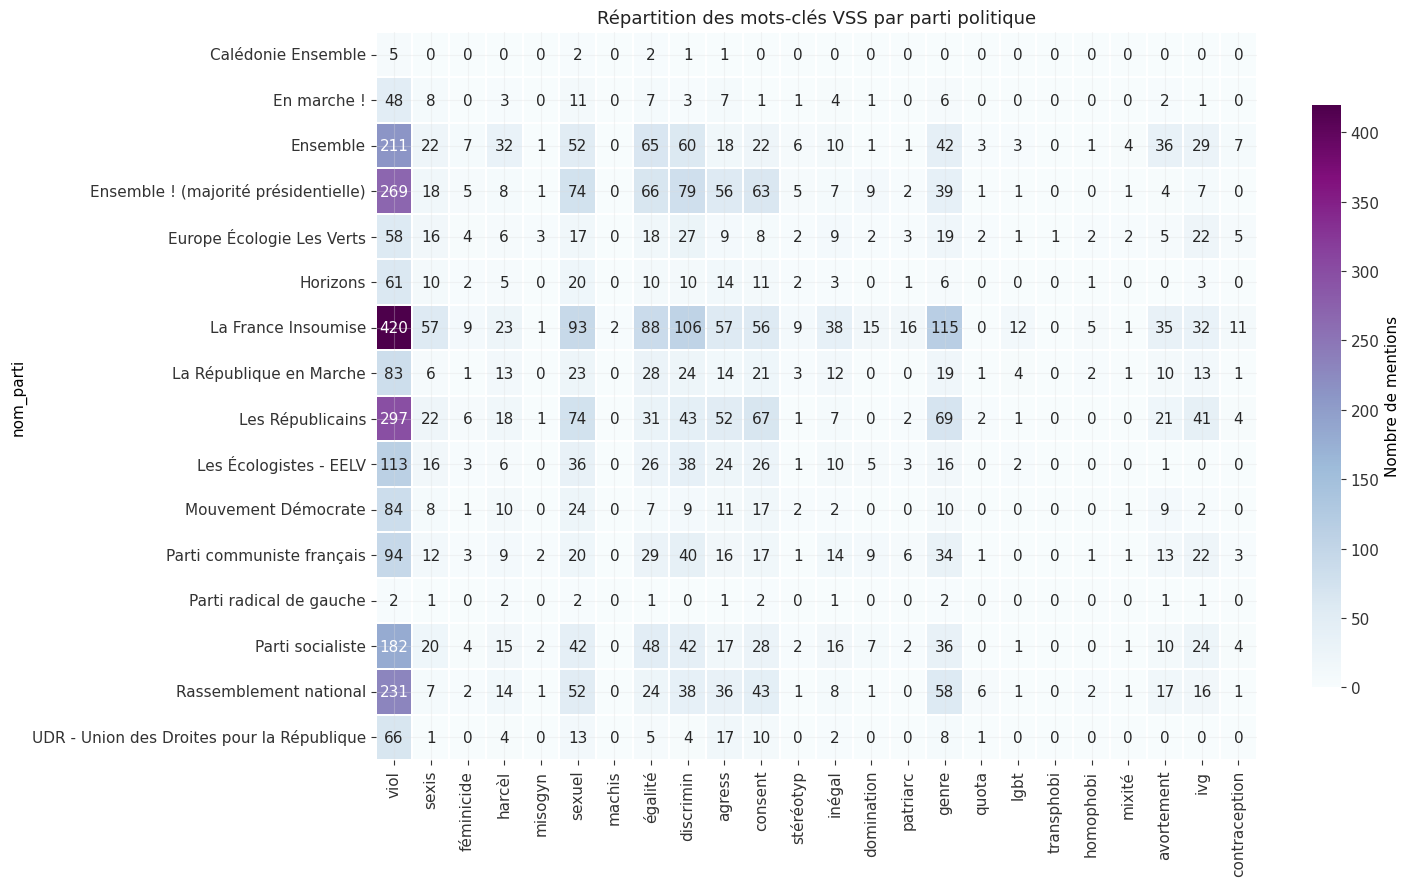

In [7]:
mots_heatmap = [
    "viol", "sexis", "féminicide", "harcèl", "misogyn",
    "sexuel", "machis", "égalité", "discrimin", "agress", "consent",
    "stéréotyp", "inégal", "domination", "patriarc", "genre", "quota",
    "lgbt", "transphobi", "homophobi", "mixité",
    "avortement", "ivg", "contraception",
]

for mot in mots_heatmap:
    df_vss[mot] = df_vss['texte'].str.contains(mot, case=False, na=False)

heatmap_data = df_vss.groupby('nom_parti')[mots_heatmap].sum()
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 10]

fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(heatmap_data, annot=True, cmap="BuPu", fmt='g',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Nombre de mentions', 'shrink': 0.8}, ax=ax)
ax.set_title("Répartition des mots-clés VSS par parti politique")
plt.tight_layout()
plt.show()

## 7. Vocabulaire identitaire dans les débats VSS

Avant même de faire l'analyse de cadrage (notebook 05), on peut mesurer combien de phrases
contiennent du vocabulaire identitaire/migratoire. C'est un indicateur brut mais parlant :
si un bloc utilise beaucoup plus ce vocabulaire que les autres, c'est qu'il relie
davantage les VSS a la question de l'immigration.

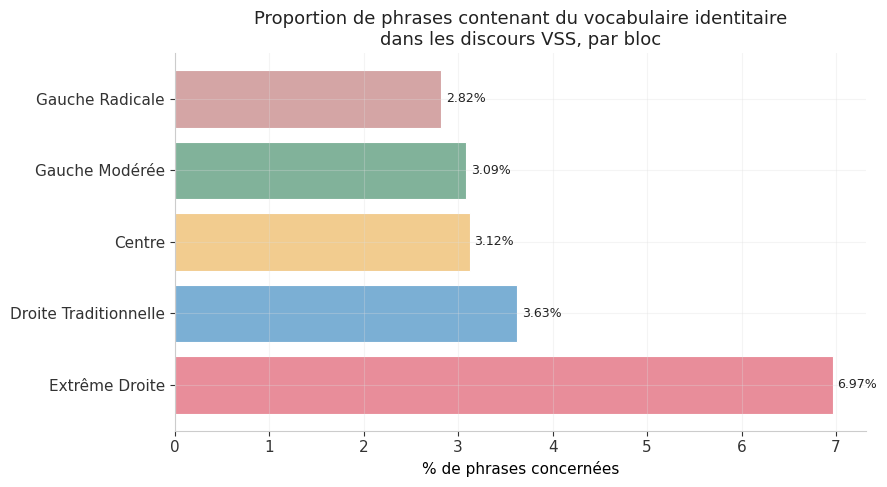

In [8]:
mots_id = ["immigration", "frontière", "clandestin", "identité", "étranger",
           "expulsion", "oqtf", "territoire", "illégal", "illégaux", "confession", "islam"]

pattern_id = re.compile(r'(?i)\b(' + '|'.join(mots_id) + r')\w*\b')
df_tmp = df_vss.copy()
df_tmp['texte'] = df_tmp['texte'].fillna('').astype(str)
df_tmp['phrases'] = df_tmp['texte'].str.split(r'[.!?]+')
df_tmp['phrases'] = df_tmp['phrases'].apply(lambda l: [p.strip() for p in l if p.strip()])
df_tmp['total_phrases'] = df_tmp['phrases'].str.len()
df_tmp['phrases_id'] = df_tmp['phrases'].apply(lambda ps: sum(1 for p in ps if pattern_id.search(p)))

agg = df_tmp.groupby('bloc')[['phrases_id', 'total_phrases']].sum()
agg['pourcentage'] = (agg['phrases_id'] / agg['total_phrases'] * 100).fillna(0)
agg = agg.sort_values('pourcentage', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COULEURS_BLOCS.get(b, '#DDD') for b in agg.index]
ax.barh(agg.index, agg['pourcentage'], color=colors, edgecolor='white', linewidth=0.8)
for i, (bloc, row) in enumerate(agg.iterrows()):
    ax.text(row['pourcentage'] + 0.05, i, f"{row['pourcentage']:.2f}%", va='center', fontsize=9)
ax.set_xlabel("% de phrases concernées")
ax.set_title("Proportion de phrases contenant du vocabulaire identitaire\ndans les discours VSS, par bloc")
plt.tight_layout()
plt.show()

## 8. Export des textes par parti

On sauvegarde les textes de chaque parti dans des fichiers `.txt` séparés.
Ils servent d'entrée pour les synthèses LLM de la section suivante.

In [9]:
output_dir = os.path.join(DOSSIER_ANALYSES, "textes_par_parti")
os.makedirs(output_dir, exist_ok=True)

for parti, group in df_vss.groupby("nom_parti"):
    nom_propre = "".join(x for x in str(parti) if x.isalnum() or x in "._- ").strip()
    with open(os.path.join(output_dir, f"{nom_propre}.txt"), "w", encoding="utf-8") as f:
        for discours in group["texte"]:
            f.write(str(discours) + "\n\n---\n\n")

print(f"Fichiers texte créés pour {len(df_vss['nom_parti'].unique())} partis dans {output_dir}")

Fichiers texte créés pour 17 partis dans /home/onyxia/work/projet_eco_socio/analyses/textes_par_parti


## 9. Syntheses LLM par bloc (Llama 3.3 70B via Open WebUI ENSAE)

On utilise une approche **Map-Reduce** pour produire une synthese de la position
de chaque bloc ideologique sur les VSS :

1. **Map** : les textes de chaque bloc sont decoupes en morceaux de ~1200 mots,
   chaque morceau est resume par Llama 3.3 (70B)
2. **Reduce** : les resumes intermediaires sont fusionnes en une synthese finale coherente

Le choix de Llama 3.3 (70B parametres) plutot que Mistral (7B) s'explique par la
meilleure capacite du modele a produire des syntheses nuancees en francais.

L'acces passe par **Open WebUI** avec une cle API personnelle (voir la doc DSIT).

In [13]:
import os
from dotenv import load_dotenv
import json
import time
import requests
import urllib3
from tqdm import tqdm

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

load_dotenv()

# Configuration API ENSAE (Open WebUI)
API_KEY = os.environ.get("ENSAE_LLM_API_KEY")
BASE_URL = "https://llm.lab.groupe-genes.fr"
MODELE_SYNTHESE = "llama3.3:latest"

# Fichiers de sauvegarde (NB: DOSSIER_ANALYSES doit être défini en amont)
fichier_syntheses = os.path.join(DOSSIER_ANALYSES, "syntheses_blocs_VSS.txt")
dossier_checkpoints = os.path.join(DOSSIER_ANALYSES, "checkpoints_map")
dossier_checkpoints_reduce = os.path.join(DOSSIER_ANALYSES, "checkpoints_reduce")
os.makedirs(dossier_checkpoints, exist_ok=True)
os.makedirs(dossier_checkpoints_reduce, exist_ok=True)

def appeler_llm_synthese(prompt, role_systeme, max_retries=5, timeout=300):
    payload = {
        "model": MODELE_SYNTHESE,
        "messages": [
            {"role": "system", "content": role_systeme},
            {"role": "user", "content": prompt}
        ],
        "stream": False,
        "options": {"temperature": 0.0}
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(
                f"{BASE_URL}/ollama/api/chat",
                headers={"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"},
                json=payload,
                timeout=timeout,
                verify=False
            )
            r.raise_for_status()
            return r.json()["message"]["content"]
        except Exception as e:
            print(f"   Tentative {attempt+1}/{max_retries} echouee : {e}")
            time.sleep(30)
    return ""

def decouper_textes(textes, max_mots=1200):
    mots = " ".join(textes).split()
    return [" ".join(mots[i:i+max_mots]) for i in range(0, len(mots), max_mots)]

# Cache 1 : On ne refait que les blocs manquants dans le fichier final
blocs_existants = set()
if os.path.exists(fichier_syntheses):
    with open(fichier_syntheses, "r", encoding="utf-8") as f:
        contenu = f.read()
    # NB: ORDRE_BLOCS doit être défini en amont
    for bloc in ORDRE_BLOCS:
        if f"=== {bloc.upper()} ===" in contenu:
            blocs_existants.add(bloc)

blocs_a_faire = [b for b in ORDRE_BLOCS if b not in blocs_existants]

if not blocs_a_faire:
    print(f"Toutes les syntheses existent deja dans {fichier_syntheses}")
else:
    print(f"Syntheses a generer : {blocs_a_faire}")

    prompt_map = (
        "Tu es un chercheur en sociologie politique neutre et rigoureux. "
        "Synthétise des discours de l'Assemblée Nationale. "
        "N'utilise QUE les informations présentes dans le texte. "
        "Conserve le ton politique des orateurs."
    )
    prompt_reduce = (
        "Tu es un politologue expert. A partir des notes de synthèse, "
        "rédige un résumé cohérent décrivant la vision de ce bloc sur les VSS. "
        "Conserve le vocabulaire spécifique utilisé."
    )

    REDUCE_BATCH_SIZE = 4

    for bloc in blocs_a_faire:
        print(f"\nBloc : {bloc}...")
        # NB: df_vss doit être défini en amont
        discours = df_vss[df_vss['bloc'] == bloc]['texte'].tolist()
        if not discours: 
            continue

        chunks = decouper_textes(discours)
        print(f"   {len(chunks)} chunks a analyser")

        # ------------------------------------------------------------------
        # Cache 2 : Gestion des points de sauvegarde (checkpoints) du Map
        # ------------------------------------------------------------------
        fichier_checkpoint = os.path.join(dossier_checkpoints, f"checkpoint_{bloc.replace(' ', '_')}.json")
        resumes = []

        if os.path.exists(fichier_checkpoint):
            with open(fichier_checkpoint, "r", encoding="utf-8") as f:
                resumes = json.load(f)
            print(f"   Reprise Map depuis la sauvegarde : {len(resumes)}/{len(chunks)} chunks deja traites.")

        for i in tqdm(range(len(resumes), len(chunks)), desc=f"Map {bloc}"):
            chunk = chunks[i]
            r = appeler_llm_synthese(
                f"Extrait du bloc '{bloc}' sur les VSS :\n\n{chunk}\n\nResume en points clés.",
                prompt_map
            )

            if r:
                resumes.append(r)
                with open(fichier_checkpoint, "w", encoding="utf-8") as f:
                    json.dump(resumes, f, ensure_ascii=False, indent=2)

            time.sleep(5)

        # ------------------------------------------------------------------
        # Phase de Reduce avec checkpoint et barre de progression
        # ------------------------------------------------------------------
        fichier_checkpoint_reduce = os.path.join(
            dossier_checkpoints_reduce, f"checkpoint_reduce_{bloc.replace(' ', '_')}.json"
        )

        reduce_round = 0
        if os.path.exists(fichier_checkpoint_reduce):
            with open(fichier_checkpoint_reduce, "r", encoding="utf-8") as f:
                checkpoint_reduce = json.load(f)
            resumes = checkpoint_reduce["resumes"]
            reduce_round = checkpoint_reduce["round"]
            print(f"   Reprise Reduce depuis la sauvegarde : round {reduce_round}, {len(resumes)} résumés restants.")

        while len(resumes) > REDUCE_BATCH_SIZE:
            reduce_round += 1
            n_lots = (len(resumes) + REDUCE_BATCH_SIZE - 1) // REDUCE_BATCH_SIZE
            print(f"   Reduce round {reduce_round} : {len(resumes)} résumés -> {n_lots} lots de {REDUCE_BATCH_SIZE}")
            nouveaux = []
            for i in tqdm(range(0, len(resumes), REDUCE_BATCH_SIZE), desc=f"Reduce r{reduce_round} {bloc}"):
                lot = "\n\n---\n\n".join(resumes[i:i+REDUCE_BATCH_SIZE])
                r = appeler_llm_synthese(
                    f"Synthese groupée pour '{bloc}':\n\n{lot}",
                    prompt_reduce,
                    timeout=600
                )
                if r:
                    nouveaux.append(r)
                else:
                    print(f"   ERREUR : echec sur un lot du reduce round {reduce_round}. Sauvegarde et arret.")
                    resumes_restants = nouveaux + resumes[i:]
                    with open(fichier_checkpoint_reduce, "w", encoding="utf-8") as f:
                        json.dump({"round": reduce_round, "resumes": resumes_restants}, f, ensure_ascii=False, indent=2)
                    raise RuntimeError(f"Reduce echoue pour {bloc} au round {reduce_round}. Relancez la cellule pour reprendre.")
                
            time.sleep(5)
            resumes = nouveaux
            with open(fichier_checkpoint_reduce, "w", encoding="utf-8") as f:
                json.dump({"round": reduce_round, "resumes": resumes}, f, ensure_ascii=False, indent=2)

        # Synthese finale
        print(f"   Synthese finale pour {bloc}...")
        toutes_notes = "\n\n---\n\n".join(resumes)
        synthese = appeler_llm_synthese(
            f"Notes finales pour '{bloc}':\n\n{toutes_notes}\n\nRedige la synthese (3 paragraphes).",
            prompt_reduce,
            timeout=600
        )

        if synthese:
            with open(fichier_syntheses, "a", encoding="utf-8") as f:
                f.write(f"=== {bloc.upper()} ===\n{synthese}\n\n")
            print(f"   Synthese de {bloc} sauvegardée.")

            if os.path.exists(fichier_checkpoint):
                os.remove(fichier_checkpoint)
            if os.path.exists(fichier_checkpoint_reduce):
                os.remove(fichier_checkpoint_reduce)

    print(f"\nToutes les syntheses sont dans {fichier_syntheses}")

Syntheses a generer : ['Centre', 'Gauche Modérée', 'Gauche Radicale']

Bloc : Centre...
   340 chunks a analyser
   Reprise Map depuis la sauvegarde : 340/340 chunks deja traites.


Map Centre: 0it [00:00, ?it/s]

Map Centre: 0it [00:00, ?it/s]

   Reduce round 1 : 340 résumés -> 85 lots de 4


Reduce r1 Centre:   0%|          | 0/85 [00:00<?, ?it/s]

...

Reduce r3 Gauche Radicale:  75%|███████▌  | 3/4 [00:18<00:05,  5.98s/it]

Reduce r3 Gauche Radicale: 100%|██████████| 4/4 [00:26<00:00,  6.97s/it]

Reduce r3 Gauche Radicale: 100%|██████████| 4/4 [00:26<00:00,  6.75s/it]

   Synthese finale pour Gauche Radicale...


   Synthese de Gauche Radicale sauvegardée.

Toutes les syntheses sont dans /home/onyxia/work/projet_eco_socio/analyses/syntheses_blocs_VSS.txt
